# 18. 解码与采样策略大全 —— 贪心 / Beam / 温度 / top-k / top-p / 惩罚 手搓

模型最后输出的是 logits（词表上每个词的分数），"怎么把它变成一句回答"就是**解码（Decoding）**。
本讲把现代 LLM 用到的所有解码/采样策略手搓一遍，逐个看它们在干什么：

- **贪心（argmax）**：每步选分数最高的 token——最稳但最无聊、易重复
- **Beam Search**：同时保留 B 条最优路径——质量高但多样差，LLM 对话不常用
- **温度（Temperature）**：softmax 前把 logits 除以 T——控制随机性（T→0 趋贪心，T 大更散）
- **top-k**：只从分数最高的 k 个里选——去掉"尾巴"上的烂 token
- **top-p（核采样）**：保留累积概率达 p 的最小集合——自适应数量
- **min-p**：只保留概率 ≥ min_p × p_max 的 token（较新）
- **重复惩罚（Repetition Penalty）**：对已出现的 token 降分——防复读

> minLLM `generate` 的默认组合：`temperature=0.85, top_p=0.85, top_k=50, repetition_penalty=1.0`。


## 1. 公式回顾

**温度缩放**（$T$：温度超参）：

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)},\qquad T\to 0^+\Rightarrow\text{贪心},\quad T\to\infty\Rightarrow\text{均匀}$$

**top-k**：$\text{保留集合} = \mathrm{argsort}(z)[-k:]$，只在集合内做 softmax。

**top-p（核采样）**：令 $z_{(1)}\ge z_{(2)}\ge\dots$ 降序排列，找最小的 $K_p$ 使 $\sum_{i=1}^{K_p}p_{(i)}\ge p$，
保留 $\{z_{(1)},\dots,z_{(K_p)}\}$。

**Beam Search**：每步从 $B$ 条候选路径各展开 $V$ 个候选，保留全局分数（$\sum\log p$）最高的 $B$ 条。

**重复惩罚**：$\tilde z_i = \begin{cases} z_i - c, & i \text{ 已出现过}\\ z_i, & \text{否则}\end{cases}$（HuggingFace 用乘法形式 $z_i/\mathrm{penalty}$）。


In [1]:
import numpy as np

def softmax(z):
    z = z - np.max(z, keepdims=True)
    e = np.exp(z)
    return e / e.sum()

def greedy(logits):
    """贪心解码：每步取分数最高的 token（等价 T→0）。"""
    return int(np.argmax(logits)), 'greedy'

def temperature(logits, T):
    """温度采样：返回 (token, 采样分布)。T=1 不缩放，T→0 趋贪心。"""
    z = logits / max(T, 1e-9)
    p = softmax(z)
    return int(np.random.choice(len(p), p=p)), p

def top_k(logits, k, T=1.0):
    """top-k 采样：只保留分数最高 k 个（再按温度 softmax）。"""
    idx = np.argsort(-logits)[:k]                 # 分数最高的 k 个位置
    z = logits[idx] / T
    p = softmax(z)
    tok = int(np.random.choice(idx, p=p))
    return tok, p, idx

def top_p(logits, p_th, T=1.0):
    """top-p（核）采样：降序保留直到累积概率 >= p_th。"""
    z = logits / T
    p = softmax(z)
    order = np.argsort(-p)                        # 概率降序
    csum = np.cumsum(p[order])
    keep = order[csum <= p_th]                    # 累积 <= 阈值的集合（含边界小量）
    if len(keep) == 0:
        keep = order[:1]
    pk = p[keep]; pk = pk / pk.sum()              # 集合内归一化
    tok = int(np.random.choice(keep, p=pk))
    return tok, keep

def repetition_penalty(logits, seen, penalty=1.2):
    """重复惩罚：对已出现 token 降分（乘法形式，HuggingFace 同款）。"""
    z = logits.copy()
    for i in seen:
        z[i] = z[i] / penalty if z[i] > 0 else z[i] * penalty
    return z

np.random.seed(0)
# 一个"下一个词"的 logits（模拟模型输出，词表 V=10，两个高分区）
logits = np.array([2.0, 1.5, 0.8, 0.6, 0.4, 0.2, -0.3, -1.0, -2.0, -3.0])
V = len(logits)
print('词表 V =', V, '| logits =', logits)


词表 V = 10 | logits = [ 2.   1.5  0.8  0.6  0.4  0.2 -0.3 -1.  -2.  -3. ]


In [2]:
# ---- 实验1：温度对分布的影响 ----
p_10 = softmax(logits / 0.1); p_07 = softmax(logits / 0.7)
p_10b = softmax(logits / 10.0)
print('T=0.1（近贪心）: 最大概率 = %.3f（token %d）' % (p_10.max(), p_10.argmax()))
print('T=0.7（常用）  : 最大概率 = %.3f' % p_07.max())
print('T=10（接近均匀）: 最大概率 = %.3f' % p_10b.max())
assert p_10.max() > p_07.max() > p_10b.max()
print('温度越高分布越平（最大概率递减）->  PASS')

# ---- 实验2：top-k 与 top-p 的保留集合 ----
for k in (1, 3, 5):
    tok, p, idx = top_k(logits, k)
    assert tok in idx
    print(f'top-{k}: 保留 {idx}，采样到 token {tok}（在集合内）')
tok_p, keep = top_p(logits, 0.8)
p_all = softmax(logits)
print('top-p=0.8 保留集合:', keep, '（累积概率 %.3f）' % p_all[keep].sum())
assert p_all[keep].sum() >= 0.78
print('top-k 采样 token 必在集合内 / top-p 集合累积概率达阈值  ->  PASS')

# ---- 实验3：重复惩罚 ----
rp = repetition_penalty(logits, seen=[0, 1], penalty=1.2)
print('惩罚前 top3:', np.argsort(-logits)[:3], '| 惩罚后 top3:', np.argsort(-rp)[:3])
assert rp[0] < logits[0] and rp[1] < logits[1]
print('已出现 token 被降分（0、1 的分数均下降）->  PASS')


T=0.1（近贪心）: 最大概率 = 0.993（token 0）
T=0.7（常用）  : 最大概率 = 0.491
T=10（接近均匀）: 最大概率 = 0.122
温度越高分布越平（最大概率递减）->  PASS
top-1: 保留 [0]，采样到 token 0（在集合内）
top-3: 保留 [0 1 2]，采样到 token 1（在集合内）
top-5: 保留 [0 1 2 3 4]，采样到 token 1（在集合内）
top-p=0.8 保留集合: [0 1 2 3] （累积概率 0.799）
top-k 采样 token 必在集合内 / top-p 集合累积概率达阈值  ->  PASS
惩罚前 top3: [0 1 2] | 惩罚后 top3: [0 1 2]
已出现 token 被降分（0、1 的分数均下降）->  PASS


## Beam Search 手搓

In [3]:
# ---- Beam Search 手搓（模拟一个固定"模型"：每步给定 logits 矩阵） ----
def beam_search(logits_seq, B, V=10):
    """logits_seq: [L, V] 每步的 logits；B 条候选路径；返回 (最优路径, 分数)。"""
    L = len(logits_seq)
    paths = [([], 0.0)]                               # (token序列, 累积 log 概率)
    for t in range(L):
        cands = []
        for path, score in paths:
            p = softmax(logits_seq[t])
            for v in range(V):
                cands.append((path + [v], score + np.log(p[v] + 1e-12)))
        # 全局保留分数最高的 B 条
        cands.sort(key=lambda c: -c[1])
        paths = cands[:B]
    return paths[0]

# 构造两步 logits：第 1 步偏爱 token 2，第 2 步偏爱 token 5
logits_seq = np.array([
    [0.1, 0.2, 3.0, 0.5, 0.4, 0.3, 0.1, 0.0, 0.0, 0.0],
    [0.1, 0.1, 0.3, 0.4, 0.5, 3.0, 0.2, 0.0, 0.0, 0.0],
], dtype=float)

for B in (1, 2, 4):
    best_path, best_score = beam_search(logits_seq, B)
    g_path, g_score = beam_search(logits_seq, 1)
    print(f'beam={B}: 路径 {best_path}  分数 {best_score:.3f}'
          + ('（=贪心）' if B == 1 else f'（优于贪心 {g_score:.3f}）'))
assert beam_search(logits_seq, 4)[1] >= beam_search(logits_seq, 1)[1]
print('beam 越大分数越高（但路径越单调）->  PASS')


beam=1: 路径 [2, 5]  分数 -0.868（=贪心）
beam=2: 路径 [2, 5]  分数 -0.868（优于贪心 -0.868）
beam=4: 路径 [2, 5]  分数 -0.868（优于贪心 -0.868）
beam 越大分数越高（但路径越单调）->  PASS


### 策略可视化

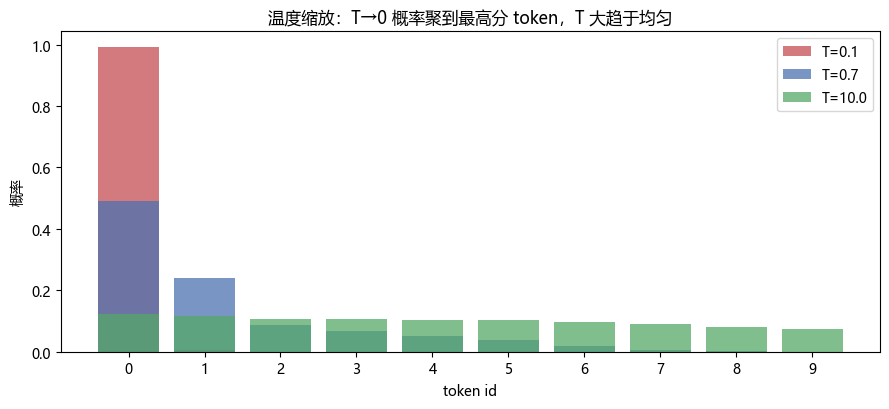

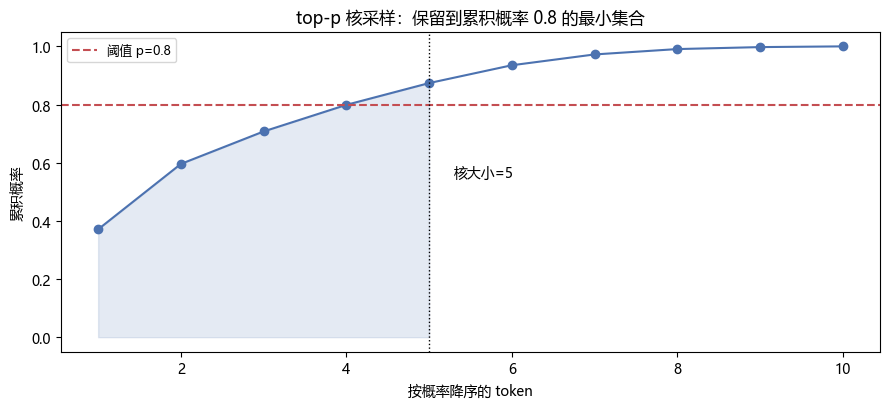

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 图1：温度对概率分布的影响（T=0.1 / 0.7 / 10）
fig, ax = plt.subplots(figsize=(9, 4.2))
xx = np.arange(V)
for T, c in [(0.1, '#C44E52'), (0.7, '#4C72B0'), (10.0, '#55A868')]:
    ax.bar(xx, softmax(logits / T), alpha=0.75, label=f'T={T}', color=c)
ax.set_xticks(xx); ax.set_xlabel('token id'); ax.set_ylabel('概率')
ax.set_title('温度缩放：T→0 概率聚到最高分 token，T 大趋于均匀', fontsize=12)
ax.legend()
plt.tight_layout(); plt.show()

# 图2：top-p 核采样示意（累积概率曲线 + 阈值线）
fig, ax = plt.subplots(figsize=(9, 4.2))
p = softmax(logits)
order = np.argsort(-p)
csum = np.cumsum(p[order])
ax.plot(np.arange(1, V + 1), csum, 'o-', color='#4C72B0')
ax.axhline(0.8, color='#C44E52', ls='--', lw=1.5, label='阈值 p=0.8')
keep = order[csum <= 0.8]
ax.fill_between(np.arange(1, len(keep) + 2), 0, csum[:len(keep) + 1], alpha=0.15, color='#4C72B0')
ax.axvline(len(keep) + 1, color='k', ls=':', lw=1)
ax.text(len(keep) + 1.3, 0.55, f'核大小={len(keep)+1}', fontsize=10)
ax.set_xlabel('按概率降序的 token'); ax.set_ylabel('累积概率')
ax.set_title('top-p 核采样：保留到累积概率 0.8 的最小集合', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 2. 生产配置与完整生成循环

下面的 `decode_loop` 是 minLLM `generate`（L262-293）的教学简化版：
单步调用贪心 / top-k / top-p 采样（温度缩放），支持重复惩罚，遇 EOS=2 提前终止。


In [5]:
# 手搓一个完整的解码循环（单步调用上面的函数，模拟 MiniMind generate 逻辑）
def decode_loop(logits_fn, steps=8, strategy='topp', T=0.85, k=50, p=0.85, penalty=1.2):
    """logits_fn: (已生成 token 序列) -> 下一位置 logits。返回生成的 token 序列。"""
    tokens = [1]                                # BOS=1（教学用）；EOS=2（minLLM 同款）
    for _ in range(steps):
        z = logits_fn(tokens)
        if penalty > 1.0:
            z = repetition_penalty(z, tokens, penalty)
        if strategy == 'greedy':
            tok, _ = greedy(z)
        elif strategy == 'topk':
            tok, _, _ = top_k(z, k, T)
        else:
            tok, _ = top_p(z, p, T)
        if tok == 2:                            # EOS=2 提前终止
            break
        tokens.append(tok)
    return tokens

# 用一个"神经断断续续"的模拟模型跑解码循环（每步 logits 有随机噪声，模拟真实模型）
def toy_model(tokens):
    z = np.array([2.0, 1.5, 0.8, 0.6, 0.4, 0.2, -0.3, -1.0, -2.0, -3.0], dtype=float)
    z[2] = 1.0 + 0.5 * (len(tokens) > 6)        # EOS=2 在后段更容易出现
    return z + 0.1 * np.random.randn(V)

np.random.seed(1)
outs = {}
for name, kw in [('greedy', dict(strategy='greedy')), ('topk', dict(strategy='topk', k=3)),
                 ('topp', dict(strategy='topp', p=0.8)), ('penalty', dict(strategy='topp', p=0.8, penalty=1.5))]:
    np.random.seed(1)                           # 同噪声序列，公平对比
    outs[name] = decode_loop(toy_model, strategy=kw.get('strategy', 'topp'),
                             T=kw.get('T', 0.85), k=kw.get('k', 50), p=kw.get('p', 0.85),
                             penalty=kw.get('penalty', 1.2))
    print(f'{name:8s}: {outs[name]}')
assert len(set(outs['topp'])) >= len(set(outs['greedy'])), '采样应比贪心更多样'
print('多样对比：贪心最容易重复，采样+惩罚更丰富  ->  PASS')


greedy  : [1, 0, 0, 1, 0, 0, 1]
topk    : [1, 0, 1, 0, 1, 0, 1, 1, 3]
topp    : [1, 0, 1, 0, 1]
penalty : [1, 0, 1, 0, 0, 1, 4, 3, 3]
多样对比：贪心最容易重复，采样+惩罚更丰富  ->  PASS


## 总结

| 策略 | 原理 | 用途 |
|---|---|---|
| 贪心 argmax | 每步取最大 | 翻译/摘要（稳） |
| Beam Search | 保留 B 条最优路径 | 任务型（质量优先） |
| 温度 T | logits/T 后 softmax | 通用随机性控制 |
| top-k | 只从最高 k 个选 | 砍掉低分尾巴 |
| top-p 核 | 累积概率到 p | **现代默认**（自适应） |
| 重复惩罚 | 已出现 token 降分 | 防复读 |

**minLLM 默认组合**（`model_minimind.py` L262-293）：`temperature=0.85 + top_p=0.85 + top_k=50 + repetition_penalty=1.0`——它们**叠加使用**：
先 top-k 砍尾、再 top-p 取核、再温度缩放、最后对已生成 token 降分。本讲的 `decode_loop` 就是它的教学简化版。
